## Constructing Galois Field of Characteristic 2

Since most of our source information is in binary, we need to construct an extended field of characteristic 2, which is $GF(2^m)$, constructed by a polynomial. I created a function called `exfield_gen` that does this. Additionally, since powers of elements are needed and the `index()` method can be slow, I saved powers of primitive elements in a list `loga`. This makes *multiplication*, *division*, and *power* operations in $GF(2^m)$ efficient. I ordered bits from **LSB** to **MSB** to match the textbook notation.

```python
def exfield_gen(m, g):
	n =(1 << m)
	x =(1 << m)
	alph =[0] * (n-1)
	loga =[0] * (n)

	for i in range(n -1):
		x = (x >> 1)
		alph[i] = x
		loga[x] = i

		if(x & 1):
			x = (x ^ g)

    return alph, loga
```

As shown, we multiply by $\alpha$ and add $g(x)$ (primitive polynomial) through XOR operation. This function provides the field elements and their corresponding power indices, which can be used to calculate *multiplication* or *division*. Addition is just normal XOR since the field has characteristic 2.


In [5]:
import gf

gf16 = gf.exfield_gen(4, 0b11001)
alph = gf16[0]
loga = gf16[1]

print(f"primitive elements (indexs are powers): {tuple(bin(i) for i in alph)} \n primitive elements powers: {tuple(loga)}")

primitive elements (indexs are powers): ('0b1000', '0b100', '0b10', '0b1', '0b1100', '0b110', '0b11', '0b1101', '0b1010', '0b101', '0b1110', '0b111', '0b1111', '0b1011', '0b1001') 
 primitive elements powers: (0, 3, 2, 6, 1, 9, 5, 11, 0, 14, 8, 13, 4, 7, 10, 12)


## Cyclic Code Encoder

I implemented a **Linear Feedback Shift Register (LFSR)** hardware model function (per cycle) to simulate the encoder used in cyclic codes and binary **BCH** codes.

```python
def lfsr(taps :int, mem :int =0, /, state :int =0, sin :bool =0):
	gate1 = (state & 1)
	state |= (sin << mem)
	if(gate1):
		state ^= taps
	else:
		state  = 0
		
	state >>= 1

	return state
```

The above code is a model based on example 4.2 in the Shun Li textbook, where `gate1` indicates the feedback input.

For the encoder, we run the message $u(x)$ for $k$ iterations, then output the state of the LFSR:

```python
def encode(n, k, /, u, g, parity =0):
    
	codeword =0b0
	taps = g ^ (g & 1)
	lfsr_par = (taps, n-k)
	# clock through n (codeword length)
	for clk in range(n):
		u_clk, u =cir.bit_pop(u)

		parity = cir.lfsr(*lfsr_par, state =parity, sin =u_clk)
		if(clk < k):
			codeword ^= (u_clk << clk)
	codeword ^= (parity <<k)

	return codeword
```


## Berlekamp-Massey Algorithm

This algorithm is used to solve the linear recursion, similar to power estimation:

<img src="img/bmflchart.jpg" alt="Berlekamp-Massey flowchart" width="500"/>

Consider the linear recursion as follows:
$$
S_k =\sum_{i}^{n-1} \Lambda_i.S_{k-i}
$$

The Berlekamp-Massey algorithm finds values of $\Lambda_i$. If there is a discrepancy, you need to subtract some multiple of the last connection polynomial $\Lambda^{(\rho)}(X)$ from $\Lambda^{(\mu)}(X)$. Due to linearity, the multiple $A$ is calculated as follows: $\Delta_\mu +A.\Delta_\rho =0 \to A = -\frac{\Delta_\mu}{\Delta_\rho}$.

In this implementation, I use $\Lambda^{\rho}(X) = B(X)$ and $\Lambda^{\mu}(X) = C(X)$ in each iteration.


## BCH Decoder Implementation

```python 
def berlekamp_massey(S :list, field):
	''' Find error locator polynomial (sigma).
	'''
	C[0] =alph[0]			 # connection poly
	B[0] =alph[0]			 # last connection poly
	L = 0               	 # connection poly length L = len(B) --> L-1 = deg(B)
	shift = 1 				 # shift = mu - rho
	d =alph[0]; b = alph[0]	 # current/last discrepancy

	for mu in range(2*t):

		# compute discrepancy
		d =S[mu]
		for i in range(1, L+1):
			d ^= mul(C[i], S[mu - i], field)

		if (d == 0):
			shift += 1
		else:
			T = C.copy()
			A = div(d, b, field)

			# Connection poly modification
			for i in range(L + 1):
				C[i + shift] ^= mul(A, B[i], field)		# correction term: A.X^m.B_i

			if (L - 1) < (mu - L):           # condition to choose 
                                             # last discrepancy where d != 0
				L = mu + 1 - L
				B = T
				b = d
				shift = 1
			else:
				shift += 1
	return C[:L+1]
```

The code above implements the Berlekamp-Massey algorithm. The Euclidean algorithm also works but has higher temporal complexity than BM (Euclidean: $O(n^3)$, BM: $O(n^2)$). After applying BM and solving the linear recursion, the `chien_search` function is called to find the roots of the locator polynomial, which correspond to the inverse of error locations. Chien search is an efficient method for evaluating polynomials using previous values.

```python
def chien_search(L :list, field):
	'''Search for roots of the locator polynomial L.
	'''
	for i in range(n):
		beta = alph[i]
		ai = alph[0]
		Lai = 0
		
		for ll in L:
			Lai^= mul(ll,   ai, field)
			ai  = mul(ai, beta, field)

		if Lai == 0:
			roots.append(beta)

	return roots
```

The above code implements Chien search and returns decimal values of the roots (not their exponents).
This method of Chien search can be used to evaluate `received polynomials` and find the `syndrome`

```python
def syndrome(n, k, t, /, r, field):
	''' calculate syndrome for binary bch.
	'''
	for i in range(2*t):
		S[i] =0
		mask =(1<<n)
		r_masked = r | mask           # mask is used to avoid 0b00101 being treated as 0b101
		for j in range(n):
			r_j = (r_masked >> (n-j-1)) & 1
			if r_j:
				aij = gf.power(a1, ((i+1)*j), field)
				S[i] ^= aij
			else:
				continue
```

After the syndrome is calculated, it is used to determine the locator and error location in the decode function:

```python
def decode(n, k, t, /, r, field):
	''' decode bch code.
	'''
	loga =field[1]
	S   = syndrome(*(n, k, t), r, field)
	Sig = berlekamp_massey(S, field)
	Sig.reverse()                     # reversed locator roots are error locations!

	err_loc = lrsolve.chien_search(Sig, field)
	mask = 1 << n
	r_masked = r | mask
	for ej in err_loc:
		r_masked ^= (1 << (n-loga[ej]-1))

	u_star = r_masked & ((1<<k)-1)       # ((1<<k)-1 is for masking or omitting the parity of r
```


## Non-binary BCH / Reed-Solomon Code

To encode an RS code, there are two approaches: textbook long division or LFSR-like division process.

```python
def encode(n, k, t, /, u: list, gen: list, field):
    '''Encode nonbinary BCH/RS-like code using an LFSR division.'''
    alph, loga = field[0], field[1]
    if len(gen) <= 1:
        return u[:]
    if gen[-1] != alph[0]:
        raise ValueError('Generator polynomial must be monic') # this should hold in BCH and RS
    
    regs = [0] * (len(gen) - 1)
    u =(regs + u).copy()        # .copy() method avoids 'u' from being overwritten
    for uu in reversed(u):      # u = [u0 u1 ... u(n-1)] -> [u(n-1) ... u1 u0]
        lead = regs[-1]
        regs[1:] = regs[:-1]
        regs[0] = uu
        if lead != 0:
            for j in range(len(gen) - 1):
                regs[j] ^= mul(lead, gen[j], field)

    return regs + u[len(regs):]
```

In the above LFSR implementation, states hold symbols instead of bits.

Similar to BCH, I use the previous BM function to find the locator (note that errors occur in symbols, not bits, so the locator shows which symbol is incorrect). The only difference is in the Forney algorithm, which is used to evaluate the error value:

<img src="img/rsflchart.jpg" alt="RS Forney flowchart" width="500"/>

In the above flowchart, the upper part is BM and the lower part is the Forney algorithm. To calculate the Forney algorithm, we need to find the error evaluator polynomial (which is a convolution function or finite impulse response filter) and the derivative function for taking the derivative of a polynomial.

```python
def conv(a :list, b :list, field) -> tuple:
	'''multiply polynomial a(x) by b(x)'''

	c = [0] *(len(a) + len(b) - 1)

	for i,ai in enumerate(a):
		for j,bj in enumerate(b):
			c[i+j] ^= mul(ai, bj, field)   # (i + j) is a nice convention of
                                          # showing where symbols add to each other

	return c
```

Since we work in binary or extended binary fields, the derivative can be computed by shifting coefficients.

```python 
def diff(a :list):
	a =a.copy()
	if (len(a) %2):
		a.pop()

	a[0::2] = a[1::2]
	a[1::2] = [0] * (len(a)//2)
	a.pop()
	return a
```

After encoding, we calculate the locator and syndrome, and from these we determine the error value for each error location. The following formula is what the Forney algorithm implements:

$$\delta_k = \frac{Z_0(\beta_k^{-1})}{\sigma'(\beta_k^{-1})}$$
where $\beta_k^{-1}$ are the $k^{th}$ roots of the `locator` polynomial $\sigma$, which is the reverse of the `error location` polynomial.
```python
def forney_algorithm(L: list, Z: list, loc, field) -> list:
    '''Calculate error values using the Forney error-evaluation formula.'''
    error_values = []
    dL = poly.diff(L)
    for wj in loc:
        try:
            dk = div(poly.eval(Z, wj, field),
                    poly.eval(dL,wj, field), field)  
            error_values.append(dk)
        except ZeroDivisionError:
            error_values.append(0)

    return error_values
```
Here `loc` is the list of `locators` roots which are inverse roots of `error location` polynomials, and `L`, `Z` represent the `locator` and `error evaluator` polynomials, respectively.
With both error locations and values, we can now correct the wrong symbols.


## Channel
Here I have used `AWGN` channel, with Shannon capacity $C = 2B.log_2(1+SNR)$, with simple `BPSK` modulation:
Assuming the transmitted symbols are equally likely, the correlation detector reduces to a sign detector
```python
def modulation(b :int, E =1):
	sm = (E**.5) *(1- 2*b)
	return sm

def demodulation(r):
	return 0 if r>0 else 1

def awgn(sm, N0=1):
	n = rn.normalvariate(0, (N0/2)**.5)
	r = sm + n
	return r

def AWGN(EbN0, stream, N0 =1, R =1):
	Eb =1.0
	Ec =R*Eb
	N0 = Ec / EbN0
	s = modulation(stream, Ec)
	r = awgn(s, N0)
	return demodulation(r)
```
The code rate changes the energy per transmitted coded bit, $E_c = R.E_b$, To account for this in the channel, we calculate the 
noise power based on the desired $E_b/N_0$

## Results
After simulating Monte Carlo for 1000 `frames` and 150 points of `snr` the following results appear:

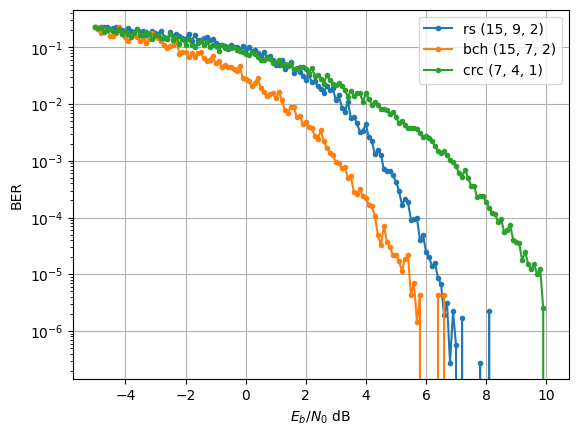

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

rs = pd.read_csv("./SIM_FILES/rs_ber.csv")
bch = pd.read_csv("./SIM_FILES/bch_ber.csv")
crc = pd.read_csv("./SIM_FILES/crc_ber.csv")

plt.figure()
plt.semilogy(rs["EbN0"], rs["BER"], marker=".", label='rs (15, 9, 2)')
plt.semilogy(bch["EbN0"], bch["BER"], marker=".", label='bch (15, 7, 2)')
plt.semilogy(crc["EbN0"], crc["BER"], marker=".", label='crc (7, 4, 1)')
plt.xlabel("$E_b/N_0$ dB")
plt.ylabel("BER")
plt.grid(True)

plt.legend()
plt.show()

Notice that Shannon limit is $C = B \times log_2(1 + SNR)$; by $R = C$, $B = 1$ and $SNR = R.E_b/N_0$ this becomes:
$$ R = log_2(1+R.E_b/N_0)$$
$$\to \frac{2^R-1}{R} = E_b/N0$$

There are some considerations here: the noise standard deviation is $\sqrt{N_0/2}$ and we use real valued AWGN:
$$ C = \frac{B}{2}log_2(1+2R.E_b/N_0)$$
$$\to \frac{2^{2R}-1}{2R} = E_b/N0$$
The $B/2$ is because of nyquist sampling theorem.

In [6]:
from math import log10
shannon_limit = lambda R: 10*log10((2**(2*R) - 1)/2/R)


Rrs = 9/15
Rbch = 7/15
Rcrc = 4/7

print(f'EbN0_min_rs = {shannon_limit(Rrs)} db', 
      f'EbN0_min_bch = {shannon_limit(Rbch)} db', 
      f'EbN0_min_crc = {shannon_limit(Rcrc)} db', sep ='\n')

EbN0_min_rs = 0.3389154624148628 db
EbN0_min_bch = -0.11146598640443595 db
EbN0_min_crc = 0.2413934560906318 db


BCH (15, 7, 2) is better at achieving lower BER than RS (15, 9, 2), but its Rate is lower than RS and uses more bits to encode information, in contrast
the RS provides high performance with less redundancy.

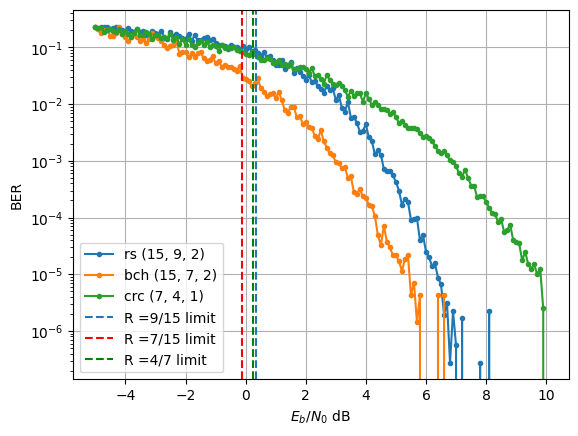

In [8]:
plt.figure()
plt.semilogy(rs["EbN0"], rs["BER"], marker=".", label='rs (15, 9, 2)')
plt.semilogy(bch["EbN0"], bch["BER"], marker=".", label='bch (15, 7, 2)')
plt.semilogy(crc["EbN0"], crc["BER"], marker=".", label='crc (7, 4, 1)')
plt.xlabel("$E_b/N_0$ dB")
plt.ylabel("BER")
plt.grid(True)

plt.axvline(shannon_limit(Rrs),
            linestyle ='--',
            label ='R =9/15 limit')
plt.axvline(shannon_limit(Rbch),
            linestyle ='--',
            color ='r',
            label ='R =7/15 limit')
plt.axvline(shannon_limit(Rcrc),
            linestyle ='--',
            color='g',
            label ='R =4/7 limit')

plt.legend()
plt.savefig("./img/BER_plot.png", dpi =300)
plt.show()